In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Resolves to this notebook's own directory in VS Code; falls back to cwd elsewhere.
# No edits needed when copying this notebook to another sample folder.
try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).parent
except NameError:
    NOTEBOOK_DIR = Path().resolve()

EST = NOTEBOOK_DIR / "outputs" / "estimates"

MODEL_ORDER = ["Naive", "GLM-MRP", "GLMER-MRP", "GLMERStan", "SRP", "MRdeeP"]

def draw_table(df, model_cols, title, note, out_path):
    """Render a state × model comparison table and save to PNG."""
    present = [c for c in model_cols if c in df.columns]
    ncols = 1 + len(present)
    nrows = len(df)

    col_labels = ["State"] + [f"{c} (%)" for c in present]
    cell_text = []
    for _, row in df[["state_name"] + present].iterrows():
        r = [row["state_name"]] + [
            f"{row[c]:.1f}" if pd.notna(row[c]) else "—" for c in present
        ]
        cell_text.append(r)

    fig_width  = 2.5 + 1.3 * len(present)
    fig_height = 0.27 * nrows + 1.4
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    tbl = ax.table(cellText=cell_text, colLabels=col_labels,
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.0)
    tbl.scale(1, 1.18)

    state_w = 0.22
    model_w = (1.0 - state_w) / len(present)
    for i in range(nrows + 1):
        tbl[i, 0].set_width(state_w)
        for j in range(1, ncols):
            tbl[i, j].set_width(model_w)

    for j in range(ncols):
        tbl[0, j].set_facecolor("#1a3a5c")
        tbl[0, j].set_text_props(color="white", fontweight="bold")

    for i in range(1, nrows + 1):
        bg = "#f0f4f8" if i % 2 == 0 else "white"
        for j in range(ncols):
            tbl[i, j].set_facecolor(bg)
            tbl[i, j].set_edgecolor("#cccccc")
        tbl[i, 0].set_text_props(ha="left", fontweight="bold")

    fig.suptitle(title, fontsize=9.5, fontweight="bold", y=0.998, ha="center")
    fig.text(0.5, 0.001, note, ha="center", fontsize=7.5,
             style="italic", color="#444444")
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")

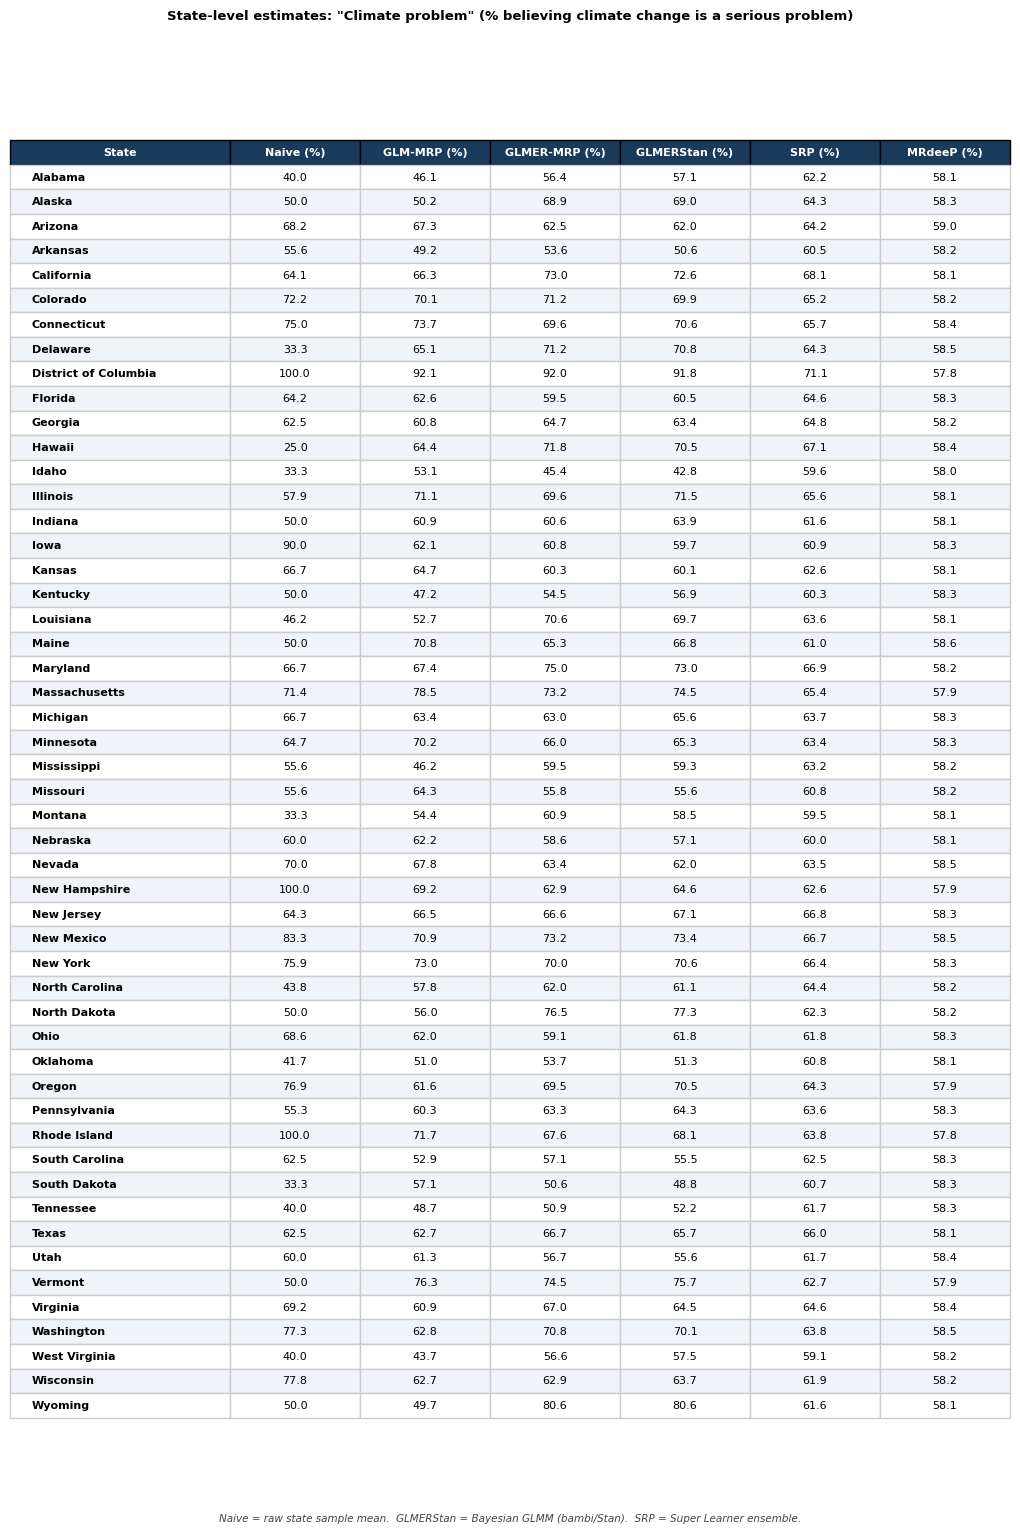

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/model_run_ces/sample1_state/outputs/estimates/table_climate_problem.png


In [4]:
# ── Climate Problem ────────────────────────────────────────────────────────────
cp = pd.read_csv(EST / "climate_problem_state_estimates.csv")
cp = cp.rename(columns={
    "baseline":  "Naive",
    "glm_mrp":   "GLM-MRP",
    "glmer_mrp": "GLMER-MRP",
    "glmerstan": "GLMERStan",
    "srp":       "SRP",
    "mrdeep":    "MRdeeP",
}).sort_values("state_name").reset_index(drop=True)

for c in MODEL_ORDER:
    if c in cp.columns:
        cp[c] = (cp[c] * 100).round(1)

draw_table(
    cp,
    model_cols=MODEL_ORDER,
    title='State-level estimates: "Climate problem" (% believing climate change is a serious problem)',
    note="Naive = raw state sample mean.  GLMERStan = Bayesian GLMM (bambi/Stan).  SRP = Super Learner ensemble.",
    out_path=EST / "table_climate_problem.png",
)

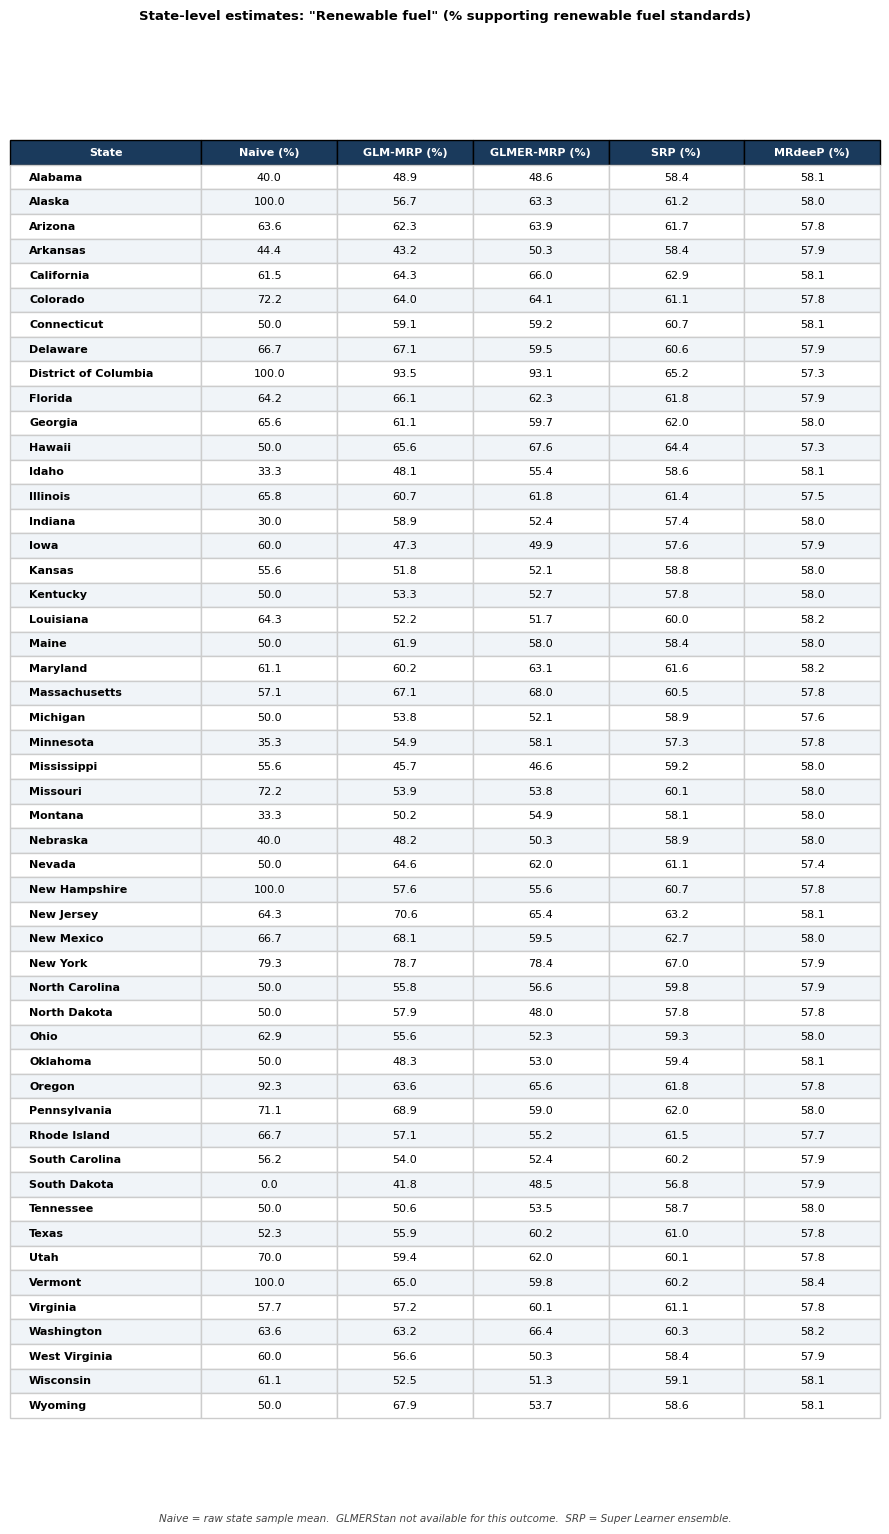

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/model_run_ces/sample1_state/outputs/estimates/table_renewable_fuel.png


In [5]:
# ── Renewable Fuel ─────────────────────────────────────────────────────────────
base = pd.read_csv(EST / "baseline_renewable_fuel_state_estimates.csv")[["state_fips","state_name","estimate"]].rename(columns={"estimate":"Naive"})
glm  = pd.read_csv(EST / "glm_mrp_renewable_fuel_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"GLM-MRP"})
glme = pd.read_csv(EST / "glmer_mrp_renewable_fuel_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"GLMER-MRP"})
srp  = pd.read_csv(EST / "srp_renewable_fuel_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"SRP"})
mrd  = pd.read_csv(EST / "mrdeep_renewable_fuel_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"MRdeeP"})

rf = (base
      .merge(glm,  on="state_fips", how="outer")
      .merge(glme, on="state_fips", how="outer")
      .merge(srp,  on="state_fips", how="outer")
      .merge(mrd,  on="state_fips", how="outer")
      .sort_values("state_name").reset_index(drop=True))

rf_models = ["Naive", "GLM-MRP", "GLMER-MRP", "SRP", "MRdeeP"]
for c in rf_models:
    if c in rf.columns:
        rf[c] = (rf[c] * 100).round(1)

draw_table(
    rf,
    model_cols=rf_models,
    title='State-level estimates: "Renewable fuel" (% supporting renewable fuel standards)',
    note="Naive = raw state sample mean.  GLMERStan not available for this outcome.  SRP = Super Learner ensemble.",
    out_path=EST / "table_renewable_fuel.png",
)